# Notebook 7 — BALD: decomporre l'incertezza (digits)

Stesso schema del Notebook 3, sui tre domini digits invece di
MNIST/FashionMNIST: carica il checkpoint e il fit di Laplace salvati dal
Notebook 6, verifica la convergenza Monte Carlo su M, poi calcola la
predittiva e la decomposizione BALD (epistemica/aleatoria/totale) su SVHN
test (source, vero held-out), MNIST test e USPS test.

Questa testa ha K=10 classi, Dp=129 (128-d + bias), dimensione K·Dp=1.290 --
diversa dal Notebook 3 (K=10 ma Dp=129 anche lì, stesso `SmallCNN`
feature_dim=128 -- la vera differenza qui è che la predittiva gira su tre
domini, non due, e il source è SVHN, molto più difficile di MNIST). Nessun
valore di M viene assunto da notebook precedenti: il controllo di
convergenza è rifatto da zero.

## Setup

In [1]:
import sys
from pathlib import Path

cwd = Path().resolve()
PROJ = cwd
while not (PROJ / "src").exists():
    PROJ = PROJ.parent
sys.path.insert(0, str(PROJ))

import numpy as np
import matplotlib.pyplot as plt
import torch

from src.digits_data import load_domain
from src.digits_model import SmallCNN32
from src.bayesian_model import extract, augment, LastLayerLaplace

MODELS_DIR = PROJ / "models" / "source_svhn"
ckpt = torch.load(MODELS_DIR / "model.pt", map_location="cpu", weights_only=False)
lap_data = np.load(MODELS_DIR / "svhn_laplace.npz")

mean, std = ckpt["source_mean"], ckpt["source_std"]
model = SmallCNN32(n_classes=ckpt["n_classes"], feature_dim=ckpt["feature_dim"])
model.load_state_dict(ckpt["state_dict"])
model.eval()

laplace = LastLayerLaplace(theta_map=lap_data["theta_map"], cov=lap_data["cov"],
                           K=int(lap_data["K"]), Dp=int(lap_data["Dp"]))
print(f"laplace: K={laplace.K} Dp={laplace.Dp} cov shape={laplace.cov.shape}")

EVAL_DOMAINS = ["svhn", "mnist", "usps"]
DOMAIN_LABELS = {"svhn": "svhn (source, held-out test)", "mnist": "mnist (target)", "usps": "usps (target)"}

Phi_aug_eval = {}
y_eval = {}
for domain in EVAL_DOMAINS:
    X_t, y_t = load_domain(domain, "test", mean, std)
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_t, y_t), batch_size=256)
    Phi, y_np, _ = extract(model, loader, device="cpu")
    Phi_aug_eval[domain] = augment(Phi)
    y_eval[domain] = y_np
    print(f"{DOMAIN_LABELS[domain]}: {Phi.shape[0]} immagini, feature {Phi.shape}")

laplace: K=10 Dp=129 cov shape=(1290, 1290)
svhn (source, held-out test): 26032 immagini, feature (26032, 128)
mnist (target): 10000 immagini, feature (10000, 128)
usps (target): 2007 immagini, feature (2007, 128)


## Controllo di convergenza epistemica vs. M

Sweep di `M_VALUES` a seed fisso, confrontato con un riferimento
indipendente `M_REFERENCE` (stesso seed, non incluso in `M_VALUES`),
richiedendo deviazione relativa e assoluta sotto soglia per una finestra di
stabilità di 3 valori consecutivi, su tutti e tre i domini
simultaneamente.

In [2]:
M_VALUES = [50, 100, 250, 500, 1000, 2000]
RNG_SEED = 123

convergence = {f"{d}_{stat}": [] for d in EVAL_DOMAINS for stat in ["total", "epi", "ale"]}
convergence["M"] = []

for M in M_VALUES:
    convergence["M"].append(M)
    line = [f"M={M:5d}:"]
    for domain in EVAL_DOMAINS:
        rng = np.random.default_rng(RNG_SEED)
        pred = laplace.predictive_batched(Phi_aug_eval[domain], M=M, rng=rng)
        convergence[f"{domain}_total"].append(pred["total"].mean())
        convergence[f"{domain}_epi"].append(pred["epistemic"].mean())
        convergence[f"{domain}_ale"].append(pred["aleatoric"].mean())
        line.append(f"{domain}_epi={pred['epistemic'].mean():.4f}")
    print("  " + "  ".join(line))

M_REFERENCE = 5000
ref_epi = {}
for domain in EVAL_DOMAINS:
    rng = np.random.default_rng(RNG_SEED)
    pred_ref = laplace.predictive_batched(Phi_aug_eval[domain], M=M_REFERENCE, rng=rng)
    ref_epi[domain] = pred_ref["epistemic"].mean()
    print(f"  {domain}: riferimento epistemica (M={M_REFERENCE}) = {ref_epi[domain]:.6f}")

epi_max = max(list(ref_epi.values()) + sum([convergence[f"{d}_epi"] for d in EVAL_DOMAINS], []))
RELATIVE_THRESHOLD = 0.01
ABSOLUTE_THRESHOLD = 0.02 * epi_max
print(f"\nsoglia assoluta: {ABSOLUTE_THRESHOLD:.6f} (2% del massimo osservato={epi_max:.6f})")

  M=   50:  svhn_epi=0.0048  mnist_epi=0.0300  usps_epi=0.0225
  M=  100:  svhn_epi=0.0049  mnist_epi=0.0307  usps_epi=0.0226
  M=  250:  svhn_epi=0.0049  mnist_epi=0.0306  usps_epi=0.0228
  M=  500:  svhn_epi=0.0049  mnist_epi=0.0303  usps_epi=0.0227
  M= 1000:  svhn_epi=0.0049  mnist_epi=0.0303  usps_epi=0.0225
  M= 2000:  svhn_epi=0.0049  mnist_epi=0.0303  usps_epi=0.0223
  svhn: riferimento epistemica (M=5000) = 0.004918
  mnist: riferimento epistemica (M=5000) = 0.030347
  usps: riferimento epistemica (M=5000) = 0.022395

soglia assoluta: 0.000614 (2% del massimo osservato=0.030705)


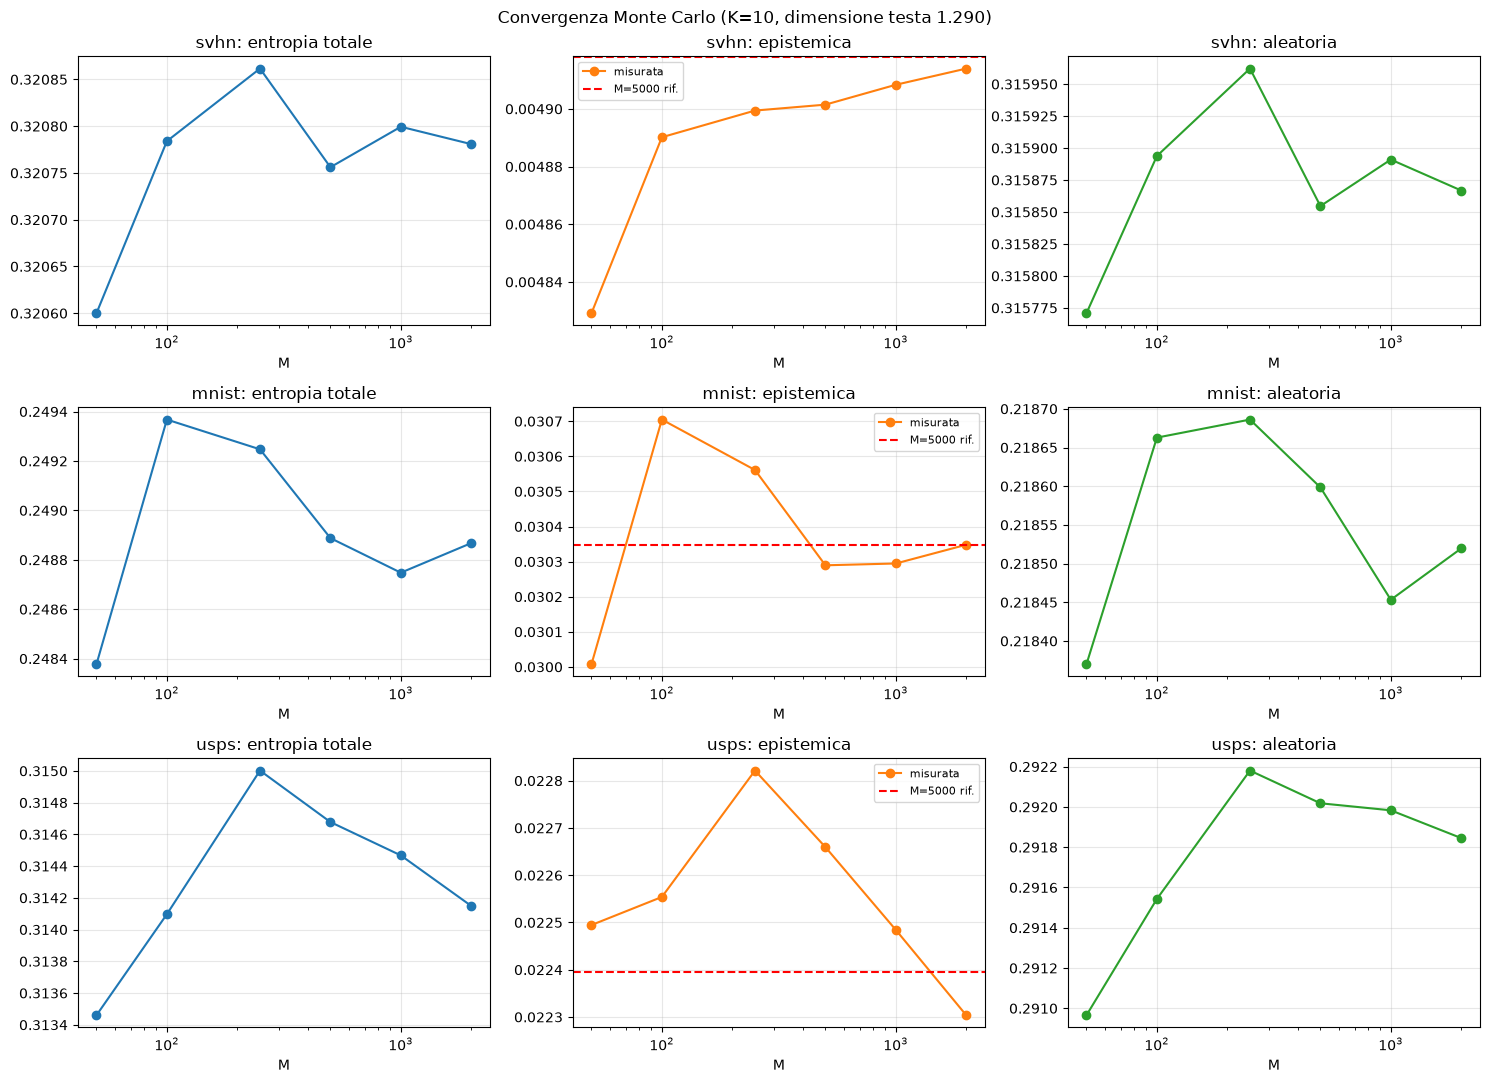

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
M_arr = np.array(convergence["M"])
for row, domain in enumerate(EVAL_DOMAINS):
    axes[row, 0].plot(M_arr, convergence[f"{domain}_total"], "o-")
    axes[row, 0].set_title(f"{domain}: entropia totale")
    axes[row, 1].plot(M_arr, convergence[f"{domain}_epi"], "o-", color="tab:orange", label="misurata")
    axes[row, 1].axhline(ref_epi[domain], color="red", linestyle="--", label=f"M={M_REFERENCE} rif.")
    axes[row, 1].set_title(f"{domain}: epistemica")
    axes[row, 1].legend(fontsize=8)
    axes[row, 2].plot(M_arr, convergence[f"{domain}_ale"], "o-", color="tab:green")
    axes[row, 2].set_title(f"{domain}: aleatoria")
    for ax in axes[row]:
        ax.set_xlabel("M")
        ax.set_xscale("log")
        ax.grid(True, alpha=0.3)
fig.suptitle("Convergenza Monte Carlo (K=10, dimensione testa 1.290)")
fig.tight_layout()
plt.show()

In [4]:
def check_point(epi_values, refs):
    return all(abs(e - r) / r < RELATIVE_THRESHOLD and abs(e - r) < ABSOLUTE_THRESHOLD
               for e, r in zip(epi_values, refs))

point_ok = []
for i, M in enumerate(convergence["M"]):
    epi_values = [convergence[f"{d}_epi"][i] for d in EVAL_DOMAINS]
    refs = [ref_epi[d] for d in EVAL_DOMAINS]
    ok = check_point(epi_values, refs)
    point_ok.append(ok)
    devs = "  ".join(f"{d}={abs(e - r) / r * 100:.2f}%" for d, e, r in zip(EVAL_DOMAINS, epi_values, refs))
    print(f"M={M:5d}  {devs}  -> {'YES' if ok else 'no'}")

WINDOW = 3
M_FIXED = None
for i, M in enumerate(convergence["M"]):
    if i + WINDOW <= len(convergence["M"]) and all(point_ok[i:i + WINDOW]):
        M_FIXED = M
        break
if M_FIXED is None:
    M_FIXED = M_REFERENCE
    print(f"\nnessun M soddisfa la finestra di stabilità su tutti e 3 i domini -> M_FIXED = M_REFERENCE = {M_FIXED}")
else:
    print(f"\nSELEZIONATO: M_FIXED = {M_FIXED}")

np.savez(MODELS_DIR / "mc_convergence.npz", M_FIXED=M_FIXED, M_REFERENCE=M_REFERENCE)
print(f"salvato {MODELS_DIR / 'mc_convergence.npz'}")

M=   50  svhn=1.81%  mnist=1.12%  usps=0.45%  -> no
M=  100  svhn=0.56%  mnist=1.18%  usps=0.71%  -> no
M=  250  svhn=0.38%  mnist=0.71%  usps=1.90%  -> no
M=  500  svhn=0.33%  mnist=0.19%  usps=1.18%  -> no
M= 1000  svhn=0.19%  mnist=0.17%  usps=0.40%  -> YES
M= 2000  svhn=0.08%  mnist=0.00%  usps=0.41%  -> YES

nessun M soddisfa la finestra di stabilità su tutti e 3 i domini -> M_FIXED = M_REFERENCE = 5000
salvato /Users/riccardo/Desktop/PML/BayesianExoAdaptation/code_v2/models/source_svhn/mc_convergence.npz


## Predittiva con M_FIXED e decomposizione BALD

In [5]:
FINAL_SEED = 456
predictive_results = {}
for domain in EVAL_DOMAINS:
    rng = np.random.default_rng(FINAL_SEED)
    pred = laplace.predictive_batched(Phi_aug_eval[domain], M=M_FIXED, rng=rng)
    predictive_results[domain] = dict(y=y_eval[domain], **pred)
    acc = (pred["probs"].argmax(axis=1) == y_eval[domain]).mean()
    print(f"{DOMAIN_LABELS[domain]}: accuracy predittiva MC={100 * acc:.2f}%")

print(f"\n{'dominio':>28s} {'n':>6s} {'epistemica':>18s} {'aleatoria':>18s} {'totale':>18s}")
print("-" * 94)
for domain in EVAL_DOMAINS:
    r = predictive_results[domain]
    print(f"{DOMAIN_LABELS[domain]:>28s} {len(r['y']):6d} "
          f"{r['epistemic'].mean():8.4f}+-{r['epistemic'].std():.4f}   "
          f"{r['aleatoric'].mean():8.4f}+-{r['aleatoric'].std():.4f}   "
          f"{r['total'].mean():8.4f}+-{r['total'].std():.4f}")

svhn (source, held-out test): accuracy predittiva MC=87.52%
mnist (target): accuracy predittiva MC=58.64%
usps (target): accuracy predittiva MC=59.64%

                     dominio      n         epistemica          aleatoria             totale
----------------------------------------------------------------------------------------------
svhn (source, held-out test)  26032   0.0049+-0.0088     0.3159+-0.4449     0.3208+-0.4514
              mnist (target)  10000   0.0303+-0.0466     0.2185+-0.3085     0.2488+-0.3494
               usps (target)   2007   0.0223+-0.0312     0.2918+-0.3565     0.3141+-0.3834


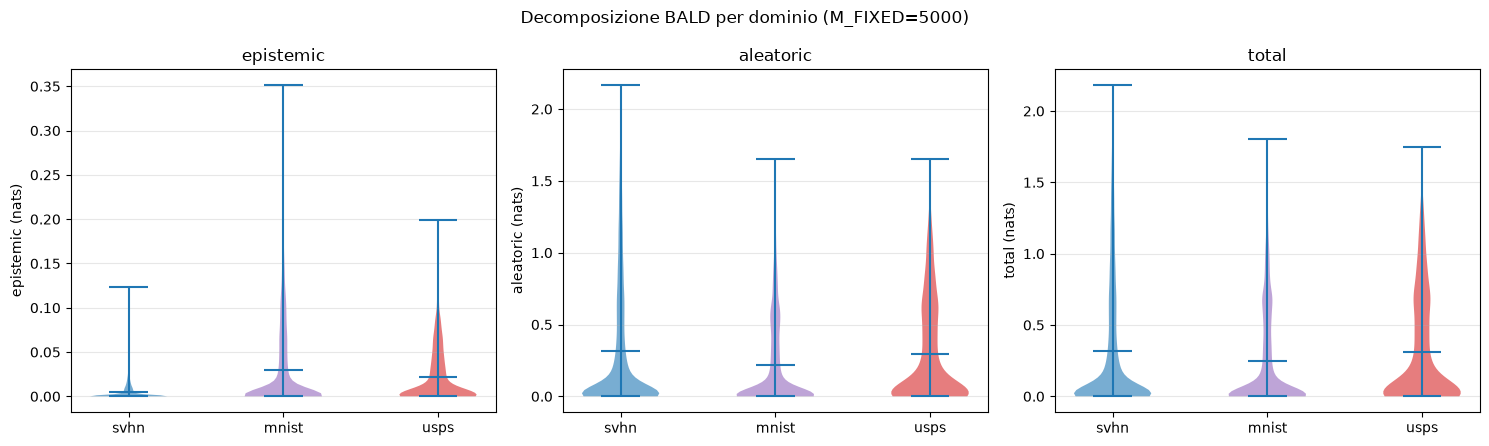

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
domain_colors = {"svhn": "tab:blue", "mnist": "tab:purple", "usps": "tab:red"}
for ax, comp in zip(axes, ["epistemic", "aleatoric", "total"]):
    data = [predictive_results[d][comp] for d in EVAL_DOMAINS]
    parts = ax.violinplot(data, showmeans=True, showextrema=True)
    for pc, d in zip(parts["bodies"], EVAL_DOMAINS):
        pc.set_facecolor(domain_colors[d])
        pc.set_alpha(0.6)
    ax.set_xticks(range(1, len(EVAL_DOMAINS) + 1))
    ax.set_xticklabels(EVAL_DOMAINS)
    ax.set_ylabel(f"{comp} (nats)")
    ax.set_title(comp)
    ax.grid(True, alpha=0.3, axis="y")
fig.suptitle(f"Decomposizione BALD per dominio (M_FIXED={M_FIXED})")
fig.tight_layout()
plt.show()

## Confronto statistico: Mann-Whitney U

I tre domini hanno numerosità diverse e non esiste un accoppiamento
naturale fra un'immagine SVHN, una MNIST e una USPS, quindi si usa
Mann-Whitney U (test a ranghi per campioni indipendenti) invece di un test
appaiato. Tutte e tre le coppie sono confronti puliti source-vs-target o
target-vs-target (nessuna etichettatura speciale necessaria, dato il vero
held-out del Notebook 6).

In [7]:
from scipy.stats import mannwhitneyu

pairs = [("svhn", "mnist"), ("svhn", "usps"), ("mnist", "usps")]
print(f"{'coppia':>18s} {'n1':>6s} {'n2':>6s} {'statistica U':>14s} {'p-value':>12s}")
print("-" * 62)
for a, b in pairs:
    xa = predictive_results[a]["epistemic"]
    xb = predictive_results[b]["epistemic"]
    stat, pval = mannwhitneyu(xa, xb, alternative="two-sided")
    print(f"{a + ' vs ' + b:>18s} {len(xa):6d} {len(xb):6d} {stat:14.1f} {pval:12.3e}")

            coppia     n1     n2   statistica U      p-value
--------------------------------------------------------------
     svhn vs mnist  26032  10000    109403224.0   6.973e-122
      svhn vs usps  26032   2007     18413249.0   6.728e-108
     mnist vs usps  10000   2007      9464512.0    5.684e-05
